In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./data/online_retail.csv', parse_dates=['InvoiceDate'])
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


属性信息:
Invoice：发票号码。唯一分配给每个事务的6位整数。如果此代码以字母“c”开头，则表示取消。
StockCode：产品（项目）代码。唯一地分配给每个不同产品的5位整数。
Description：产品（项）名称。
Quantity：每笔交易中每个产品（项目）的数量。数字。
InvoiceDate：发票日期和时间。数字。事务生成的日期和时间。
Price：单价。数字。产品单价为英镑（Â£）。
CustomerID：客户号。名义。唯一分配给每个客户的5位整数。
Country：国家名称。名义。客户所在国家的名称。

In [3]:
df.dtypes

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [4]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [5]:
df.nunique()

Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

In [6]:
print(f"负数占比：{(df['Quantity'] < 0).mean().round(4) * 100}%")
print(f"UK占比：{(df['Country'] == 'United Kingdom').mean().round(4)*100}%")

负数占比：2.15%
UK占比：91.94%


In [7]:
monthly_count = df.resample('ME', on='InvoiceDate').size()
print(monthly_count)

InvoiceDate
2009-12-31    45228
2010-01-31    31555
2010-02-28    29388
2010-03-31    41511
2010-04-30    34057
2010-05-31    35323
2010-06-30    39983
2010-07-31    33383
2010-08-31    33306
2010-09-30    42091
2010-10-31    59098
2010-11-30    78015
2010-12-31    65004
2011-01-31    35147
2011-02-28    27707
2011-03-31    36748
2011-04-30    29916
2011-05-31    37030
2011-06-30    36874
2011-07-31    39518
2011-08-31    35284
2011-09-30    50226
2011-10-31    60742
2011-11-30    84711
2011-12-31    25526
Freq: ME, dtype: int64


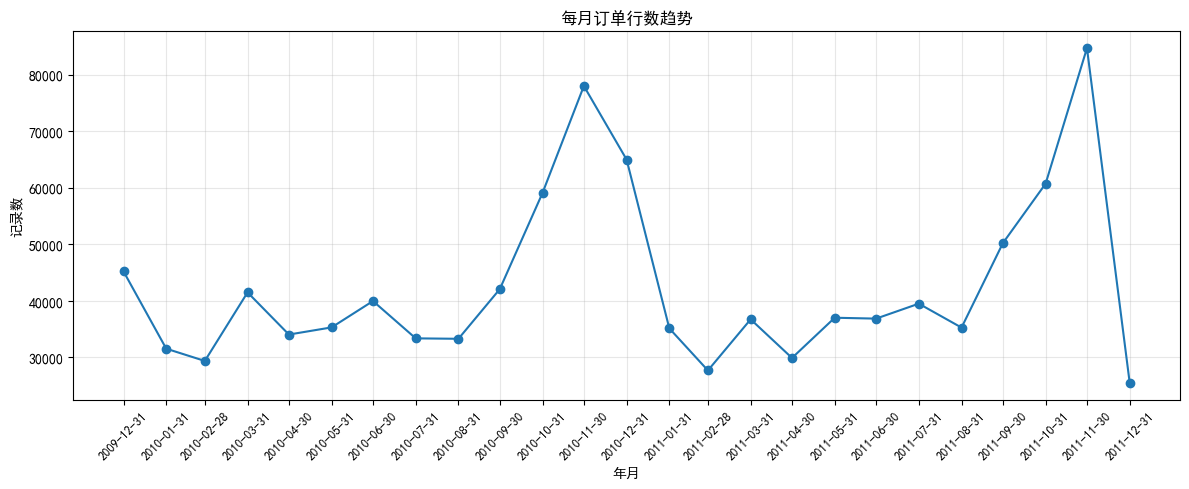

In [8]:
plt.rcParams['font.family'] = 'SimHei'  # 替换为你选择的字体
plt.figure(figsize=(12, 5))
plt.plot(monthly_count.index, monthly_count.values, marker='o')  # 加个圆点，每个月看得更清楚
plt.xticks(monthly_count.index, rotation=45, fontsize=9)
plt.title('每月订单行数趋势')
plt.xlabel('年月')
plt.ylabel('记录数')
plt.grid(alpha=0.3)   # 加网格线，读数更方便
plt.tight_layout()
plt.show()

In [9]:
# 基本统计
print(f"Price = 0 的行数: {(df['Price'] == 0).sum()}")
print(f"Price < 0 的行数: {(df['Price'] < 0).sum()}")
print(f"Price 的最小值: {df['Price'].min()}")
print(f"Price 的最大值: {df['Price'].max()}")

Price = 0 的行数: 6202
Price < 0 的行数: 5
Price 的最小值: -53594.36
Price 的最大值: 38970.0


In [10]:
#Price = 0 的样本（前 10 行）:
df[df['Price'] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1062442,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
1064015,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


In [22]:
#Price < 0 的样本:
df[df['Price'] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [12]:
# 看所有 InvoiceNo 的首字母分布
prefix = df['Invoice'].astype(str).str[0]
print("Invoice 首字符分布:")
print(prefix.value_counts())

Invoice 首字符分布:
Invoice
5    939382
4    108489
C     19494
A         6
Name: count, dtype: int64


In [26]:
prefix.value_counts()['C'] / len(df) * 100

np.float64(1.8263565339511754)

In [13]:
# 具体看看非数字开头的
non_numeric_invoice = df[~df['Invoice'].astype(str).str[0].str.isdigit()]
print(f"\n非数字开头的 Invoice 数量: {len(non_numeric_invoice)}")


非数字开头的 Invoice 数量: 19500


In [23]:
# 样本:
non_numeric_invoice[['Invoice', 'StockCode', 'Quantity', 'Price', 'Description']]

,Invoice,StockCode,Quantity,Price,Description
178,C489449,22087,-12,2.95,PAPER BUNTING WHITE LACE
179,C489449,85206A,-6,1.65,CREAM FELT EASTER EGG BASKET
180,C489449,21895,-4,4.25,POTTING SHED SOW 'N' GROW SET
181,C489449,21896,-6,2.10,POTTING SHED TWINE
182,C489449,22083,-12,2.95,PAPER CHAIN KIT RETRO SPOT
...,...,...,...,...,...
1065910,C581490,23144,-11,0.83,ZINC T-LIGHT HOLDER STARS SMALL
1067002,C581499,M,-1,224.69,Manual
1067176,C581568,21258,-5,10.95,VICTORIAN SEWING BOX LARGE
1067177,C581569,84978,-1,1.25,HANGING HEART JAR T-LIGHT HOLDER


In [15]:
# 关键验证：C 开头的 InvoiceNo 的 Quantity 都是负数吗？
df[df['Invoice'].astype(str).str.startswith('C')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [16]:
missing_cust = df[df['Customer ID'].isna()]
not_missing = df[df['Customer ID'].notna()]

print(f"CustomerID 缺失的行数: {len(missing_cust)}")
print(f"CustomerID 缺失占比: {len(missing_cust) / len(df) * 100:.1f}%")

CustomerID 缺失的行数: 243007
CustomerID 缺失占比: 22.8%


In [17]:
# 假设 1：是不是某些国家特有的？
print("\n缺失 CustomerID 的 Country 分布 TOP 10:")
print(missing_cust['Country'].value_counts().head(10))


缺失 CustomerID 的 Country 分布 TOP 10:
Country
United Kingdom          240029
EIRE                      1671
Hong Kong                  364
Unspecified                232
France                     128
Switzerland                125
Portugal                   116
United Arab Emirates       114
Bahrain                     67
Israel                      47
Name: count, dtype: int64


In [18]:
# 假设 2：是不是特定时间段的数据问题？
print("\n缺失 CustomerID 的月份分布:")
print(missing_cust['InvoiceDate'].dt.to_period('M').value_counts().sort_index())


缺失 CustomerID 的月份分布:
InvoiceDate
2009-12    13468
2010-01     9116
2010-02     5482
2010-03     8397
2010-04     6224
2010-05     5719
2010-06     8033
2010-07     5637
2010-08     6364
2010-09     6705
2010-10     8537
2010-11    16525
2010-12    23351
2011-01    13235
2011-02     7344
2011-03     8926
2011-04     6718
2011-05     8122
2011-06     9038
2011-07    12016
2011-08     7622
2011-09     9404
2011-10    10047
2011-11    19113
2011-12     7864
Freq: M, Name: count, dtype: int64


In [19]:
# 假设 3：这些订单的 Quantity 和 UnitPrice 正常吗？
print("\n缺失 CustomerID 的 Quantity/UnitPrice 描述:")
print(missing_cust[['Quantity', 'Price']].describe())


缺失 CustomerID 的 Quantity/UnitPrice 描述:
            Quantity          Price
count  243007.000000  243007.000000
mean        1.540548       7.948744
std        98.859370     224.275451
min     -9600.000000  -53594.360000
25%         1.000000       1.660000
50%         1.000000       3.290000
75%         2.000000       5.790000
max     10200.000000   25111.090000


In [20]:
# 假设 4：这些订单是取消单吗？
print(f"缺失 CustomerID 的订单中，C 开头的占比:{missing_cust['Invoice'].astype(str).str.startswith('C').mean() * 100:.1f}%")

缺失 CustomerID 的订单中，C 开头的占比:0.3%


In [21]:
print(f"英国客户订单缺失占比：{len(missing_cust) / (df['Country'] == 'United Kingdom').sum() * 100:.2f}%")

英国客户订单缺失占比：24.76%
